# Guía de Ejercicios 2 — Inteligencia Artificial

## Modelos gráficos probabilísticos con PyMC

Sergio Hernández — `shernandez@ucm.cl` — Universidad Católica del Maule

---

En esta guía trabajaremos con **redes bayesianas**: representación de la
incertidumbre mediante grafos dirigidos acíclicos, independencia condicional e
inferencia diagnóstica.

La guía original usa `pgmpy`, que manipula tablas de probabilidad conjunta.
Aquí usamos **PyMC**, que es una biblioteca de *programación probabilística*:
se declara un **modelo generativo** y todas las probabilidades se estiman
**simulando** casos a partir de él.

| `pgmpy` | PyMC |
|---|---|
| `JointProbabilityDistribution([...])` | `pm.Categorical` sobre los estados conjuntos |
| `d.marginal_distribution(['A'])` | frecuencia relativa en la muestra |
| `d.check_independence(['A'],['B'])` | `independencia_mc(muestra, 'A', 'B')` |
| `BayesianModel([('A','C'), ...])` | `pm.Model` con `pm.Bernoulli` anidadas |
| `model.fit(datos)` | `pm.sample` con priors Beta sobre las CPT |
| `model.is_active_trail('A','B')` | `camino_activo(aristas, 'A', 'B')` |

### El método: simular y contar

Un modelo generativo permite fabricar casos. Para estimar $P(A, B)$ se simulan
cien mil pacientes, se cuenta en qué fracción ocurren ambos eventos, y esa
fracción **es** la estimación. Para condicionar en evidencia, se descartan los
casos que no la cumplen y se cuenta sobre el resto.

La ventaja: es el mismo procedimiento para tres variables o para tres mil, y no
requiere fórmulas nuevas. El costo: toda estimación trae **error de muestreo**,
y hay que saber cuánto.

Por eso, en cada sección compararemos la estimación con el valor **teórico**
calculado a mano. Esa comparación es el hilo conductor de toda la guía.

### Contenidos

1. Repaso de probabilidad — **Ejercicios 1 y 2**
2. Independencia condicional en grafos — **Ejercicios 3, 4 y 5**
3. Red Bayesiana *Asia* — **Ejercicios 6, 7 y 8**

Las celdas marcadas con `# TODO` son las que hay que completar. Cada ejercicio
termina con una verificación automática que imprime `OK` o `REVISAR`.

In [1]:
# Instalación (descomentar la primera vez)
# !pip install pymc networkx pandas matplotlib

import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import networkx as nx

SEMILLA = 42
print("PyMC", pm.__version__)

PyMC 6.3.1


---
## 0. Caja de herramientas

Cuatro funciones bastan para toda la guía: simular, estimar, comparar contra la
teoría y chequear independencia.

Una advertencia de Python: **`df.T` no es la variable `T`, es la transpuesta**
del DataFrame. En la red Asia hay una variable llamada `T`, así que siempre
usaremos `df["T"]` con corchetes.

> Ejecute la celda y siga adelante; no es necesario leerla en detalle la primera
> vez.

In [2]:
def muestrear(modelo, n=50_000, semilla=SEMILLA):
    # Simula n casos del modelo generativo (muestreo directo, sin MCMC).
    with modelo:
        previa = pm.sample_prior_predictive(draws=n, random_seed=semilla)
    nombres = ([v.name for v in modelo.free_RVs]
               + [d.name for d in modelo.deterministics])
    return pd.DataFrame({v: previa.prior[v].values.reshape(-1) for v in nombres})


def _mascara(df, condicion):
    m = pd.Series(True, index=df.index)
    for var, val in (condicion or {}).items():
        m &= df[var] == val
    return m


def p(df, evento, dado=None):
    # Estimacion Monte Carlo de P(evento | dado).
    # Devuelve (estimacion, error_estandar, n_casos_utilizados).
    base = _mascara(df, dado)
    n = int(base.sum())
    if n == 0:
        return np.nan, np.nan, 0
    est = float((base & _mascara(df, evento)).sum()) / n
    # Piso de varianza 1/n: si no ocurre ningun caso la varianza binomial es
    # cero y el error estandar quedaria nulo, lo que hace explotar cualquier
    # cociente. El piso es la correccion de continuidad habitual.
    se = np.sqrt(max(est * (1 - est), 1.0 / n) / n)
    return est, se, n


def comparar(nombre, teorico, estimacion, umbral=4.0):
    # Contrasta un valor teorico con su estimacion Monte Carlo.
    # El criterio es la distancia en errores estandar, no la diferencia bruta:
    # con n grande se exige mas precision que con n chico.
    est, se, n = estimacion
    z = abs(est - teorico) / se if se and se > 0 else np.inf
    marca = "OK      " if z < umbral else "REVISAR "
    print(f"[{marca}] {nombre:<26s} teoria {teorico:7.4f}   "
          f"MC {est:7.4f} +/- {2 * se:.4f}   n={n:>6d}   z={min(z, 999):5.1f}")
    return z < umbral


def independencia_mc(df, X, Y, Z=(), umbral=4.0, n_min=200):
    # Contrasta P(x,y|z) = P(x|z)P(y|z) en la muestra.
    # Devuelve (compatible_con_independencia, maxima_discrepancia_estandarizada).
    # La discrepancia se mide en errores estandar: una diferencia real pero mas
    # pequena que el ruido de muestreo NO se puede detectar con esta muestra.
    X = [X] if isinstance(X, str) else list(X)
    Y = [Y] if isinstance(Y, str) else list(Y)
    Z = [Z] if isinstance(Z, str) else list(Z)
    vals = {v: sorted(df[v].unique()) for v in X + Y + Z}
    z_max = 0.0
    for zc in (itertools.product(*[vals[v] for v in Z]) if Z else [()]):
        ev = dict(zip(Z, zc))
        if int(_mascara(df, ev).sum()) < n_min:
            continue
        for xc in itertools.product(*[vals[v] for v in X]):
            ex = dict(zip(X, xc))
            px = p(df, ex, ev)[0]
            for yc in itertools.product(*[vals[v] for v in Y]):
                ey = dict(zip(Y, yc))
                py = p(df, ey, ev)[0]
                pxy, se, _ = p(df, {**ex, **ey}, ev)
                if se and se > 0:
                    z_max = max(z_max, abs(pxy - px * py) / se)
    return (z_max < umbral), min(z_max, 999.0)


def tabla_2x2(df, A="A", B="B"):
    # Tabla 2x2 con marginales, en el formato del enunciado
    lineas = [f"{'':4s} {B:>8s} {B + chr(39):>8s} {'Marginal':>9s}"]
    for etiqueta, a in [(f"{A} ", 1), (f"{A}'", 0)]:
        pb = p(df, {A: a, B: 1})[0]
        pnb = p(df, {A: a, B: 0})[0]
        lineas.append(f"{etiqueta:4s} {pb:8.4f} {pnb:8.4f} {pb + pnb:9.4f}")
    cb = p(df, {B: 1})[0]
    cnb = p(df, {B: 0})[0]
    lineas.append(f"{'Marg':4s} {cb:8.4f} {cnb:8.4f} {cb + cnb:9.4f}")
    return "\n".join(lineas)


def d_separado(aristas, X, Y, Z=()):
    # Criterio GRAFICO (Bayes-Ball). No depende de los numeros de las CPT.
    g = nx.DiGraph(aristas)
    conv = lambda s: {s} if isinstance(s, str) else set(s)
    return nx.is_d_separator(g, conv(X), conv(Y), conv(Z))


def camino_activo(aristas, X, Y, Z=()):
    # Equivalente a BayesianModel.is_active_trail de pgmpy
    return not d_separado(aristas, X, Y, Z)


def cpt(tabla):
    # Tabla de probabilidad condicional indexable por los valores de los padres
    return pt.as_tensor(np.asarray(tabla, dtype="float64"))


def check(nombre, condicion, pista=""):
    print(f"[{'OK      ' if condicion else 'REVISAR '}] {nombre}"
          + (f"   -> {pista}" if (not condicion and pista) else ""))
    return bool(condicion)


print("Herramientas cargadas.")

Herramientas cargadas.


---
# 1. Repaso de probabilidad

**Convención de índices** (la misma de `pgmpy` y del enunciado): el estado `1`
significa que el evento **ocurre** y el estado `0` que **no ocurre**. Es decir
`A_1` = $A$ y `A_0` = $A'$.

Hay dos formas de declarar $P(A,B)$ en PyMC, y conviene tener ambas a mano:

In [3]:
def modelo_conjunto(p_joint):
    # Forma 1: la conjunta explicita, al estilo de pgmpy.
    # El estado k de la Categorical codifica el par (A,B) mediante k = 2*A + B,
    # de modo que p_joint sigue el orden [P(A0,B0), P(A0,B1), P(A1,B0), P(A1,B1)].
    with pm.Model() as modelo:
        AB = pm.Categorical("AB", p=np.asarray(p_joint))
        pm.Deterministic("A", AB // 2)
        pm.Deterministic("B", AB % 2)
    return modelo


def modelo_factorizado(p_A, p_B_dado_A, p_B_dado_noA):
    # Forma 2: P(A,B) = P(A) P(B|A), que es como se declara una red bayesiana.
    with pm.Model() as modelo:
        A = pm.Bernoulli("A", p_A)
        pm.Bernoulli("B", pt.switch(pt.eq(A, 1), p_B_dado_A, p_B_dado_noA))
    return modelo

## 1.1 Eventos mutuamente excluyentes

Dos eventos son mutuamente excluyentes cuando $P(A,B) = 0$: no pueden ocurrir
al mismo tiempo. Con $P(A) = 0.2$ y $P(B) = 0.7$:

| | $B$ | $B'$ | Marginal |
|---|---|---|---|
| $A$ | 0.00 | 0.20 | 0.20 |
| $A'$ | 0.70 | 0.10 | 0.80 |
| Marginal | 0.70 | 0.30 | 1.00 |

Simulamos 50 000 casos y reconstruimos esa tabla contando.

In [4]:
# Orden pgmpy: [P(A0B0), P(A0B1), P(A1B0), P(A1B1)] = [0.1, 0.7, 0.2, 0.0]
mc_excl = muestrear(modelo_conjunto([0.10, 0.70, 0.20, 0.00]))

print("Tabla estimada por muestreo:")
print(tabla_2x2(mc_excl))

print("\nContraste con los valores del enunciado:")
comparar("P(A)",    0.20, p(mc_excl, {"A": 1}))
comparar("P(B)",    0.70, p(mc_excl, {"B": 1}))
comparar("P(A,B)",  0.00, p(mc_excl, {"A": 1, "B": 1}))
comparar("P(A',B)", 0.70, p(mc_excl, {"A": 0, "B": 1}))

indep, z = independencia_mc(mc_excl, "A", "B")
print(f"\nA _|_ B ?  -> {indep}   (discrepancia maxima: {z:.1f} errores estandar)")

Sampling: [AB]


Tabla estimada por muestreo:
            B       B'  Marginal
A      0.0000   0.2002    0.2002
A'     0.7004   0.0994    0.7998
Marg   0.7004   0.2996    1.0000

Contraste con los valores del enunciado:
[OK      ] P(A)                       teoria  0.2000   MC  0.2002 +/- 0.0036   n= 50000   z=  0.1
[OK      ] P(B)                       teoria  0.7000   MC  0.7004 +/- 0.0041   n= 50000   z=  0.2
[OK      ] P(A,B)                     teoria  0.0000   MC  0.0000 +/- 0.0000   n= 50000   z=  0.0
[OK      ] P(A',B)                    teoria  0.7000   MC  0.7004 +/- 0.0041   n= 50000   z=  0.2

A _|_ B ?  -> False   (discrepancia maxima: 999.0 errores estandar)


> **La trampa clásica.** Excluyentes **no** es lo mismo que independientes; es
> lo contrario. Si $A$ ocurre, $B$ se vuelve imposible: saber $A$ cambia
> radicalmente $P(B)$. Ambas nociones sólo coinciden en el caso degenerado en
> que uno de los eventos tiene probabilidad 0.

Note que $P(A,B) = 0$ se estima con error **exactamente** cero: ningún caso
simulado tiene ambos eventos, porque el modelo no puede generarlos. Las
probabilidades 0 y 1 son las únicas que el muestreo acierta sin ruido.

---
## Ejercicio 1 — Eventos no mutuamente excluyentes

Ahora $A$ y $B$ pueden ocurrir simultáneamente: $P(A) = 0.2$, $P(B) = 0.7$ y
$P(A,B) = 0.15$.

**Complete el vector `p_joint`** con las cuatro probabilidades conjuntas en el
orden `[P(A'B'), P(A'B), P(AB'), P(AB)]`. Use que las filas y columnas deben
sumar a las marginales dadas.

In [5]:
# P(AB) = 0.15 dado.  P(AB') = P(A) - P(AB) = 0.20 - 0.15 = 0.05
# P(A'B) = P(B) - P(AB) = 0.70 - 0.15 = 0.55.  P(A'B') = 1 - el resto = 0.25
p_joint = [0.25, 0.55, 0.05, 0.15]

mc_noexcl = muestrear(modelo_conjunto(p_joint))
print(tabla_2x2(mc_noexcl))

Sampling: [AB]


            B       B'  Marginal
A      0.1501   0.0501    0.2002
A'     0.5515   0.2483    0.7998
Marg   0.7016   0.2984    1.0000


In [6]:
# Verificacion automatica
comparar("P(A)",   0.20, p(mc_noexcl, {"A": 1}))
comparar("P(B)",   0.70, p(mc_noexcl, {"B": 1}))
comparar("P(A,B)", 0.15, p(mc_noexcl, {"A": 1, "B": 1}))

# Regla aditiva: P(A u B) = P(A) + P(B) - P(A,B)
pa = p(mc_noexcl, {"A": 1})[0]
pb = p(mc_noexcl, {"B": 1})[0]
pab = p(mc_noexcl, {"A": 1, "B": 1})[0]
print(f"\nP(A) + P(B) - P(A,B) = {pa + pb - pab:.4f}")
print(f"1 - P(A',B')         = {1 - p(mc_noexcl, {'A': 0, 'B': 0})[0]:.4f}")

[OK      ] P(A)                       teoria  0.2000   MC  0.2002 +/- 0.0036   n= 50000   z=  0.1
[OK      ] P(B)                       teoria  0.7000   MC  0.7016 +/- 0.0041   n= 50000   z=  0.8
[OK      ] P(A,B)                     teoria  0.1500   MC  0.1501 +/- 0.0032   n= 50000   z=  0.1

P(A) + P(B) - P(A,B) = 0.7517
1 - P(A',B')         = 0.7517


## 1.2 Eventos independientes

$A$ y $B$ son independientes si $P(A,B) = P(A)P(B) = 0.2 \times 0.7 = 0.14$.

In [7]:
mc_indep = muestrear(modelo_conjunto([0.24, 0.56, 0.06, 0.14]))
print(tabla_2x2(mc_indep))

print()
comparar("P(A,B) = P(A)P(B)", 0.14, p(mc_indep, {"A": 1, "B": 1}))
comparar("P(B|A)  = P(B)",    0.70, p(mc_indep, {"B": 1}, {"A": 1}))
comparar("P(B|A') = P(B)",    0.70, p(mc_indep, {"B": 1}, {"A": 0}))

indep, z = independencia_mc(mc_indep, "A", "B")
print(f"\nA _|_ B ?  -> {indep}   (discrepancia maxima: {z:.1f} errores estandar)")

Sampling: [AB]


            B       B'  Marginal
A      0.1400   0.0602    0.2002
A'     0.5612   0.2386    0.7998
Marg   0.7013   0.2987    1.0000

[OK      ] P(A,B) = P(A)P(B)          teoria  0.1400   MC  0.1400 +/- 0.0031   n= 50000   z=  0.0
[OK      ] P(B|A)  = P(B)             teoria  0.7000   MC  0.6995 +/- 0.0092   n= 10010   z=  0.1
[OK      ] P(B|A') = P(B)             teoria  0.7000   MC  0.7017 +/- 0.0046   n= 39990   z=  0.7

A _|_ B ?  -> True   (discrepancia maxima: 0.3 errores estandar)


---
## Ejercicio 2 — Eventos dependientes y regla del producto

Ahora $P(A) = 0.2$, $P(B) = 0.7$ y $P(B \mid A) = 0.4$. La regla general
multiplicativa dice

$$P(A, B) = P(B \mid A)\, P(A)$$

Esta vez usaremos `modelo_factorizado`, que necesita $P(B \mid A)$ **y**
$P(B \mid A')$. Sólo tenemos la primera, así que hay que despejar la segunda a
partir de la marginal de $B$:

$$P(B) = P(B \mid A)P(A) + P(B \mid A')P(A')$$

**(a)** Complete el cálculo de `p_B_dado_noA`.
**(b)** Complete el cálculo de $P(A \mid B)$ **usando el teorema de Bayes**
(la fórmula, no la muestra) para después contrastarlo con la estimación.

In [8]:
p_A, p_B, p_B_dado_A = 0.2, 0.7, 0.4

# (a) P(B|A') = (P(B) - P(B|A)P(A)) / P(A')
p_B_dado_noA = (p_B - p_B_dado_A * p_A) / (1 - p_A)

# (b) Teorema de Bayes
p_A_dado_B = p_B_dado_A * p_A / p_B

mc_dep = muestrear(modelo_factorizado(p_A, p_B_dado_A, p_B_dado_noA))
print(f"P(B|A') = {p_B_dado_noA:.4f}\n")
print(tabla_2x2(mc_dep))

Sampling: [A, B]


P(B|A') = 0.7750

            B       B'  Marginal
A      0.0791   0.1190    0.1981
A'     0.6227   0.1792    0.8019
Marg   0.7017   0.2983    1.0000


In [9]:
# Verificacion automatica: la conjunta del enunciado es [0.18, 0.62, 0.12, 0.08]
comparar("P(A',B')", 0.18, p(mc_dep, {"A": 0, "B": 0}))
comparar("P(A',B)",  0.62, p(mc_dep, {"A": 0, "B": 1}))
comparar("P(A,B')",  0.12, p(mc_dep, {"A": 1, "B": 0}))
comparar("P(A,B)",   0.08, p(mc_dep, {"A": 1, "B": 1}))
comparar("P(B)",     0.70, p(mc_dep, {"B": 1}))

# Su respuesta (b) contra la estimacion por muestreo
comparar("P(A|B) por Bayes", p_A_dado_B, p(mc_dep, {"A": 1}, {"B": 1}))

indep, z = independencia_mc(mc_dep, "A", "B")
print(f"\nA _|_ B ?  -> {indep}   (discrepancia maxima: {z:.1f} errores estandar)")

[OK      ] P(A',B')                   teoria  0.1800   MC  0.1792 +/- 0.0034   n= 50000   z=  0.4
[OK      ] P(A',B)                    teoria  0.6200   MC  0.6227 +/- 0.0043   n= 50000   z=  1.2
[OK      ] P(A,B')                    teoria  0.1200   MC  0.1190 +/- 0.0029   n= 50000   z=  0.7
[OK      ] P(A,B)                     teoria  0.0800   MC  0.0791 +/- 0.0024   n= 50000   z=  0.8
[OK      ] P(B)                       teoria  0.7000   MC  0.7017 +/- 0.0041   n= 50000   z=  0.8
[OK      ] P(A|B) por Bayes           teoria  0.1143   MC  0.1127 +/- 0.0034   n= 35086   z=  1.0

A _|_ B ?  -> False   (discrepancia maxima: 49.7 errores estandar)


### Cuánta muestra hace falta

Toda estimación por muestreo trae error, y ese error **no** depende de cuántas
variables tenga el modelo: sólo del tamaño de la muestra. Baja como
$1/\sqrt{n}$, lo que tiene una consecuencia incómoda: para ganar un decimal hay
que multiplicar la muestra por cien.

Sampling: [A, B]


Sampling: [A, B]


Sampling: [A, B]


Sampling: [A, B]


Sampling: [A, B]


Sampling: [A, B]


Sampling: [A, B]


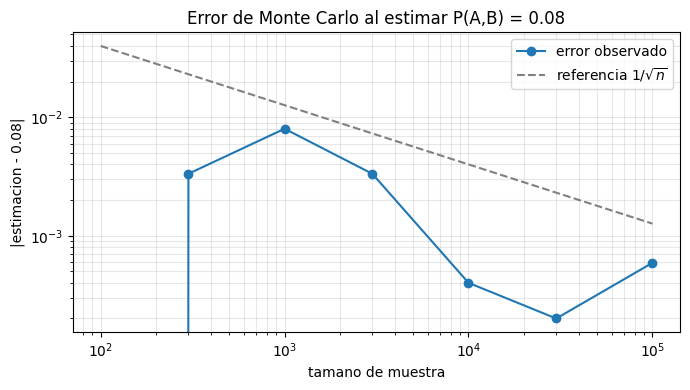

In [10]:
tamanos = [100, 300, 1_000, 3_000, 10_000, 30_000, 100_000]
errores = []
for n in tamanos:
    muestra = muestrear(modelo_factorizado(p_A, p_B_dado_A, p_B_dado_noA), n=n)
    errores.append(abs(p(muestra, {"A": 1, "B": 1})[0] - 0.08))

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(tamanos, errores, "o-", label="error observado")
ax.loglog(tamanos, [0.4 / np.sqrt(n) for n in tamanos], "--",
          color="gray", label=r"referencia $1/\sqrt{n}$")
ax.set_xlabel("tamano de muestra"); ax.set_ylabel("|estimacion - 0.08|")
ax.set_title("Error de Monte Carlo al estimar P(A,B) = 0.08")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

---
# 2. Independencia condicional en grafos

Todo DAG se descompone en tres estructuras básicas. Saber cuál es cuál es la
destreza central de esta unidad:

| Estructura | Grafo | Sin condicionar | Condicionando en $C$ |
|---|---|---|---|
| Cadena causal | $A \to C \to B$ | dependientes | **independientes** |
| Causa común | $A \leftarrow C \to B$ | dependientes | **independientes** |
| Efecto común (colisionador) | $A \to C \leftarrow B$ | **independientes** | dependientes |

El colisionador es el caso contraintuitivo, y es exactamente la condición (1)
del criterio de separación del enunciado: un nodo de aristas convergentes
bloquea el camino **salvo** que él o alguno de sus descendientes esté en $Z$.

## 2.1 Cadena causal $A \to C \to B$

Las CPT se declaran como tensores indexables por el valor del padre:
`cpt([0.2, 0.9])[A]` es $P(C=1 \mid A)$, con 0.2 si $A=0$ y 0.9 si $A=1$.

Los valores teóricos salen de la **ley de probabilidad total**. Por ejemplo:

$$P(B=1 \mid A=1) = \sum_c P(B=1 \mid c)\, P(c \mid A=1) = 0.8 \times 0.9 + 0.1 \times 0.1 = 0.73$$

In [11]:
with pm.Model() as m_cadena:
    A = pm.Bernoulli("A", 0.3)
    C = pm.Bernoulli("C", cpt([0.2, 0.9])[A])     # P(C=1|A)
    pm.Bernoulli("B", cpt([0.1, 0.8])[C])         # P(B=1|C)

mc_cadena = muestrear(m_cadena, n=100_000)
aristas_cadena = [("A", "C"), ("C", "B")]

# Valores teoricos por ley de probabilidad total
teo_C = 0.3 * 0.9 + 0.7 * 0.2                      # P(C=1)
teo_B = teo_C * 0.8 + (1 - teo_C) * 0.1            # P(B=1)

comparar("P(C=1)",     teo_C, p(mc_cadena, {"C": 1}))
comparar("P(B=1)",     teo_B, p(mc_cadena, {"B": 1}))
comparar("P(B=1|A=1)", 0.9 * 0.8 + 0.1 * 0.1, p(mc_cadena, {"B": 1}, {"A": 1}))
comparar("P(B=1|A=0)", 0.2 * 0.8 + 0.8 * 0.1, p(mc_cadena, {"B": 1}, {"A": 0}))

print("\nAl condicionar en C, el valor de A deja de importar (teoria: 0.8):")
comparar("P(B=1|C=1,A=1)", 0.8, p(mc_cadena, {"B": 1}, {"C": 1, "A": 1}))
comparar("P(B=1|C=1,A=0)", 0.8, p(mc_cadena, {"B": 1}, {"C": 1, "A": 0}))

print()
for Z in ([], ["C"]):
    indep, z = independencia_mc(mc_cadena, "A", "B", Z)
    cond = " | C" if Z else "    "
    print(f"  A _|_ B{cond} -> {str(indep):5s} (z = {z:5.1f})   "
          f"d-separados: {d_separado(aristas_cadena, 'A', 'B', Z)}")

Sampling: [A, B, C]


[OK      ] P(C=1)                     teoria  0.4100   MC  0.4096 +/- 0.0031   n=100000   z=  0.3
[OK      ] P(B=1)                     teoria  0.3870   MC  0.3879 +/- 0.0031   n=100000   z=  0.6
[OK      ] P(B=1|A=1)                 teoria  0.7300   MC  0.7308 +/- 0.0051   n= 29990   z=  0.3
[OK      ] P(B=1|A=0)                 teoria  0.2400   MC  0.2410 +/- 0.0032   n= 70010   z=  0.6

Al condicionar en C, el valor de A deja de importar (teoria: 0.8):
[OK      ] P(B=1|C=1,A=1)             teoria  0.8000   MC  0.8026 +/- 0.0049   n= 26938   z=  1.1
[OK      ] P(B=1|C=1,A=0)             teoria  0.8000   MC  0.8016 +/- 0.0067   n= 14019   z=  0.5

  A _|_ B     -> False (z = 119.4)   d-separados: False
  A _|_ B | C -> True  (z =   0.5)   d-separados: True


---
## Ejercicio 3 — Causa común (Figura 1 del enunciado)

Construya el modelo $A \leftarrow C \to B$ con

$$P(C=1) = 0.4, \quad P(A=1 \mid C) = \begin{cases}0.7 & C=1\\ 0.1 & C=0\end{cases},
\quad P(B=1 \mid C) = \begin{cases}0.9 & C=1\\ 0.2 & C=0\end{cases}$$

y verifique que $P(A,B) \neq P(A)P(B)$ pero $P(A,B \mid C) = P(A \mid C)P(B \mid C)$.

**Ojo con el orden de declaración**: en PyMC un nodo sólo puede usar variables
ya definidas, así que $C$ va primero.

In [12]:
with pm.Model() as m_causa:
    C = pm.Bernoulli("C", 0.4)
    A = pm.Bernoulli("A", cpt([0.1, 0.7])[C])   # P(A=1|C)
    B = pm.Bernoulli("B", cpt([0.2, 0.9])[C])   # P(B=1|C)

mc_causa = muestrear(m_causa, n=100_000)
aristas_causa = [("C", "A"), ("C", "B")]

Sampling: [A, B, C]


In [13]:
# Valores teoricos por ley de probabilidad total
teo_A = 0.4 * 0.7 + 0.6 * 0.1                     # P(A=1)  = 0.34
teo_B = 0.4 * 0.9 + 0.6 * 0.2                     # P(B=1)  = 0.48
teo_AB = 0.4 * 0.7 * 0.9 + 0.6 * 0.1 * 0.2        # P(A,B)  = 0.264

comparar("P(C=1)",     0.40, p(mc_causa, {"C": 1}))
comparar("P(A=1|C=1)", 0.70, p(mc_causa, {"A": 1}, {"C": 1}))
comparar("P(B=1|C=0)", 0.20, p(mc_causa, {"B": 1}, {"C": 0}))
comparar("P(A=1)",   teo_A,  p(mc_causa, {"A": 1}))
comparar("P(A,B)",   teo_AB, p(mc_causa, {"A": 1, "B": 1}))

print(f"\nP(A)P(B) = {teo_A * teo_B:.4f}, pero P(A,B) = {teo_AB:.4f}: dependientes.")
print("Condicionando en C la factorizacion se restablece:")
comparar("P(A,B|C=1)", 0.7 * 0.9, p(mc_causa, {"A": 1, "B": 1}, {"C": 1}))
comparar("P(A,B|C=0)", 0.1 * 0.2, p(mc_causa, {"A": 1, "B": 1}, {"C": 0}))

print()
for Z in ([], ["C"]):
    indep, z = independencia_mc(mc_causa, "A", "B", Z)
    cond = " | C" if Z else "    "
    print(f"  A _|_ B{cond} -> {str(indep):5s} (z = {z:5.1f})   "
          f"d-separados: {d_separado(aristas_causa, 'A', 'B', Z)}")

print()
check("A y B dependientes", not independencia_mc(mc_causa, "A", "B")[0])
check("A y B independientes dado C", independencia_mc(mc_causa, "A", "B", ["C"])[0])

[OK      ] P(C=1)                     teoria  0.4000   MC  0.3993 +/- 0.0031   n=100000   z=  0.5
[OK      ] P(A=1|C=1)                 teoria  0.7000   MC  0.6989 +/- 0.0046   n= 39928   z=  0.5
[OK      ] P(B=1|C=0)                 teoria  0.2000   MC  0.2006 +/- 0.0033   n= 60072   z=  0.4
[OK      ] P(A=1)                     teoria  0.3400   MC  0.3396 +/- 0.0030   n=100000   z=  0.3
[OK      ] P(A,B)                     teoria  0.2640   MC  0.2631 +/- 0.0028   n=100000   z=  0.7

P(A)P(B) = 0.1632, pero P(A,B) = 0.2640: dependientes.
Condicionando en C la factorizacion se restablece:
[OK      ] P(A,B|C=1)                 teoria  0.6300   MC  0.6287 +/- 0.0048   n= 39928   z=  0.5
[OK      ] P(A,B|C=0)                 teoria  0.0200   MC  0.0200 +/- 0.0011   n= 60072   z=  0.1

  A _|_ B     -> False (z = 119.2)   d-separados: False
  A _|_ B | C -> True  (z =   0.3)   d-separados: True

[OK      ] A y B dependientes
[OK      ] A y B independientes dado C


True

> **Nota sobre la Figura 1.** El enunciado la titula «cadena causal o causa
> común» y mezcla ambas miniaturas. Conviene separarlas: la cadena
> $A \to C \to B$ y la causa común $A \leftarrow C \to B$ tienen **la misma
> firma de independencias** —por eso son indistinguibles con datos puramente
> observacionales— pero son causalmente distintas. Intervenir sobre $C$ produce
> efectos diferentes en cada una.

---
## Ejercicio 4 — Efecto común y *explaining away* (Figura 2)

Construya el colisionador $A \to C \leftarrow B$ con un descendiente $D$:

- $P(A=1) = P(B=1) = 0.5$
- $P(C=1 \mid A, B)$: 0.05 si ninguna causa, 0.6 si sólo $B$, 0.7 si sólo $A$,
  0.95 si ambas. Con dos padres la tabla se indexa `cpt(tabla)[A, B]`, donde la
  fila es $A$ y la columna es $B$.
- $P(D=1 \mid C)$: 0.9 si $C=1$, 0.1 si $C=0$.

In [14]:
with pm.Model() as m_colision:
    A = pm.Bernoulli("A", 0.5)
    B = pm.Bernoulli("B", 0.5)
    # P(C=1|A,B) indexada [A, B]
    C = pm.Bernoulli("C", cpt([[0.05, 0.60], [0.70, 0.95]])[A, B])
    pm.Bernoulli("D", cpt([0.1, 0.9])[C])

mc_col = muestrear(m_colision, n=100_000)
aristas_col = [("A", "C"), ("B", "C"), ("C", "D")]

Sampling: [A, B, C, D]


In [15]:
# Teoria: como A y B son uniformes, P(C=1) es el promedio de la tabla
teo_C = (0.05 + 0.60 + 0.70 + 0.95) / 4                  # 0.575
teo_C_dado_B = (0.60 + 0.95) / 2                         # P(C=1|B=1) = 0.775
teo_B_dado_C = teo_C_dado_B * 0.5 / teo_C                # Bayes -> 0.6739
teo_C_dado_A = (0.70 + 0.95) / 2                         # P(C=1|A=1) = 0.825
teo_B_dado_CA = 0.95 * 0.5 / teo_C_dado_A                # -> 0.5758

comparar("P(C=1)",         teo_C,         p(mc_col, {"C": 1}))
comparar("P(A,B)",         0.25,          p(mc_col, {"A": 1, "B": 1}))
comparar("P(B=1|C=1)",     teo_B_dado_C,  p(mc_col, {"B": 1}, {"C": 1}))
comparar("P(B=1|C=1,A=1)", teo_B_dado_CA, p(mc_col, {"B": 1}, {"C": 1, "A": 1}))

print()
for Z in ([], ["C"], ["D"]):
    indep, z = independencia_mc(mc_col, "A", "B", Z)
    etiqueta = f"A _|_ B{' | ' + Z[0] if Z else '    '}"
    print(f"  {etiqueta:12s} -> {str(indep):5s} (z = {z:5.1f})   "
          f"d-separados: {d_separado(aristas_col, 'A', 'B', Z)}")

print()
check("A y B independientes a priori", independencia_mc(mc_col, "A", "B")[0])
check("A y B dependientes dado C", not independencia_mc(mc_col, "A", "B", ["C"])[0])
check("A y B dependientes dado D (descendiente del colisionador)",
      not independencia_mc(mc_col, "A", "B", ["D"])[0])

print("\nExplaining away: al observar el efecto C, saber que A ocurrio")
print("hace MENOS probable a B, porque A ya 'explica' el efecto.\n")
print(f"  P(B)     = {p(mc_col, {'B': 1})[0]:.4f}")
print(f"  P(B|C)   = {p(mc_col, {'B': 1}, {'C': 1})[0]:.4f}")
print(f"  P(B|C,A) = {p(mc_col, {'B': 1}, {'C': 1, 'A': 1})[0]:.4f}")

[OK      ] P(C=1)                     teoria  0.5750   MC  0.5762 +/- 0.0031   n=100000   z=  0.7
[OK      ] P(A,B)                     teoria  0.2500   MC  0.2511 +/- 0.0027   n=100000   z=  0.8
[OK      ] P(B=1|C=1)                 teoria  0.6739   MC  0.6730 +/- 0.0039   n= 57615   z=  0.5
[OK      ] P(B=1|C=1,A=1)             teoria  0.5758   MC  0.5765 +/- 0.0049   n= 41463   z=  0.3

  A _|_ B      -> True  (z =   0.1)   d-separados: True
  A _|_ B | C  -> False (z = 112.8)   d-separados: False
  A _|_ B | D  -> False (z =  50.1)   d-separados: False

[OK      ] A y B independientes a priori
[OK      ] A y B dependientes dado C
[OK      ] A y B dependientes dado D (descendiente del colisionador)

Explaining away: al observar el efecto C, saber que A ocurrio
hace MENOS probable a B, porque A ya 'explica' el efecto.

  P(B)     = 0.4999
  P(B|C)   = 0.6730
  P(B|C,A) = 0.5765


---
## Ejercicio 5 — Criterio gráfico

La d-separación es un criterio **puramente estructural**: no depende de los
números de las CPT ni del tamaño de la muestra. Por eso `camino_activo` recibe
una lista de aristas y no un modelo PyMC.

Antes de ejecutar nada, **prediga** el resultado de cada consulta y anótelo en
el diccionario. La celda siguiente compara sus predicciones con el algoritmo.

In [16]:
modelo_1 = [("A", "C"), ("C", "B")]             # cadena
modelo_2 = [("A", "C"), ("B", "C")]             # colisionador

predicciones = {
    "modelo_1: is_active_trail(A, B)":        True,   # cadena abierta
    "modelo_1: is_active_trail(A, B | C)":    False,  # C bloquea la cadena
    "modelo_2: is_active_trail(A, B)":        False,  # colisionador cerrado
    "modelo_2: is_active_trail(A, B | C)":    True,   # observar C lo abre
}

In [17]:
reales = {
    "modelo_1: is_active_trail(A, B)":     camino_activo(modelo_1, "A", "B"),
    "modelo_1: is_active_trail(A, B | C)": camino_activo(modelo_1, "A", "B", ["C"]),
    "modelo_2: is_active_trail(A, B)":     camino_activo(modelo_2, "A", "B"),
    "modelo_2: is_active_trail(A, B | C)": camino_activo(modelo_2, "A", "B", ["C"]),
}
for k, v in reales.items():
    check(f"{k:38s} = {v}", predicciones[k] == v, f"usted predijo {predicciones[k]}")

[OK      ] modelo_1: is_active_trail(A, B)        = True
[OK      ] modelo_1: is_active_trail(A, B | C)    = False
[OK      ] modelo_2: is_active_trail(A, B)        = False
[OK      ] modelo_2: is_active_trail(A, B | C)    = True


> **Errata del enunciado.** La salida impresa en la guía para
> `model2.get_independencies()` lista `(A ⊥ B | C)`, `(A ⊥ C | B)` y
> `(C ⊥ B | A)`. Eso corresponde a un grafo **sin aristas**, no al colisionador
> `A → C ← B`. En un colisionador la única independencia es `(A ⊥ B)`, y
> condicionar en `C` es justamente lo que la destruye. Compruébelo arriba.

### Aprendizaje de parámetros desde datos

Donde `pgmpy` ofrece `model.fit(datos)` para estimar las CPT por máxima
verosimilitud, PyMC hace estimación **bayesiana**: se ponen priors sobre las
probabilidades y se obtiene una distribución posterior sobre cada entrada de la
CPT, no un único número.

In [18]:
rng = np.random.default_rng(0)
n = 1000
A_obs = rng.binomial(1, 0.35, n)
C_obs = rng.binomial(1, np.where(A_obs == 1, 0.80, 0.15))
B_obs = rng.binomial(1, np.where(C_obs == 1, 0.75, 0.20))

with pm.Model() as m_fit:
    p_A_ = pm.Beta("p_A", 1, 1)
    p_C_ = pm.Beta("p_C", 1, 1, shape=2)        # P(C=1|A=0), P(C=1|A=1)
    p_B_ = pm.Beta("p_B", 1, 1, shape=2)        # P(B=1|C=0), P(B=1|C=1)
    pm.Bernoulli("A", p_A_, observed=A_obs)
    pm.Bernoulli("C", p_C_[A_obs], observed=C_obs)
    pm.Bernoulli("B", p_B_[C_obs], observed=B_obs)
    idata_fit = pm.sample(1000, tune=1000, chains=2, cores=1,
                          random_seed=1, progressbar=False)

post = idata_fit.posterior
print(f"  P(A=1)     = {float(post['p_A'].mean()):.3f}   (real 0.35)")
print(f"  P(C=1|A=0) = {float(post['p_C'][..., 0].mean()):.3f}   (real 0.15)")
print(f"  P(C=1|A=1) = {float(post['p_C'][..., 1].mean()):.3f}   (real 0.80)")
print(f"  P(B=1|C=0) = {float(post['p_B'][..., 0].mean()):.3f}   (real 0.20)")
print(f"  P(B=1|C=1) = {float(post['p_B'][..., 1].mean()):.3f}   (real 0.75)")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [p_A, p_C, p_B]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 2 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


  P(A=1)     = 0.375   (real 0.35)
  P(C=1|A=0) = 0.137   (real 0.15)
  P(C=1|A=1) = 0.782   (real 0.80)
  P(B=1|C=0) = 0.200   (real 0.20)
  P(B=1|C=1) = 0.743   (real 0.75)


---
# 3. La red Bayesiana *Asia*

Sistema de diagnóstico para enfermedades de tórax (Lauritzen & Spiegelhalter,
1988), el ejemplo canónico de la literatura.

| Nodo | Significado |
|---|---|
| `A` | visita reciente a Asia |
| `S` | fumador |
| `T` | tuberculosis |
| `L` | cáncer de laringe / pulmón |
| `B` | bronquitis |
| `E` | *either*: $T \lor L$ |
| `X` | radiografía positiva |
| `D` | disnea |

Visitar Asia aumenta la probabilidad de tuberculosis; fumar aumenta la de
cáncer y de bronquitis. El diagnóstico se apoya en dos observables: la
radiografía y la disnea.

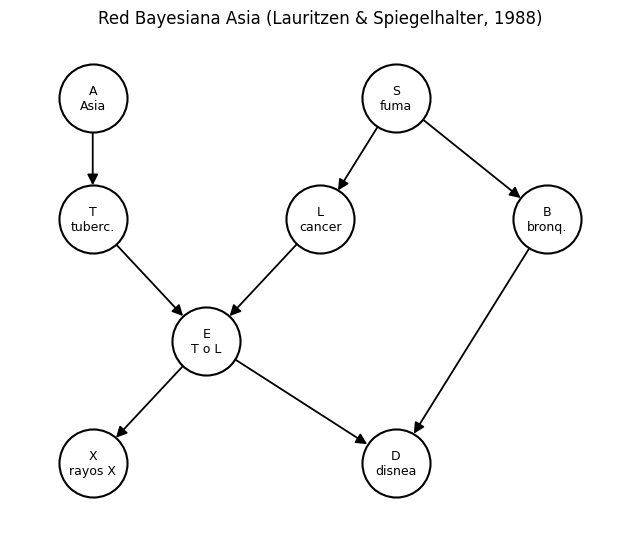

In [19]:
ARISTAS_ASIA = [("A", "T"), ("S", "L"), ("S", "B"), ("T", "E"),
                ("L", "E"), ("E", "X"), ("E", "D"), ("B", "D")]

POS = {"A": (0, 3), "S": (2, 3), "T": (0, 2), "L": (1.5, 2),
       "B": (3, 2), "E": (0.75, 1), "X": (0, 0), "D": (2, 0)}
ETIQ = {"A": "A\nAsia", "S": "S\nfuma", "T": "T\ntuberc.", "L": "L\ncancer",
        "B": "B\nbronq.", "E": "E\nT o L", "X": "X\nrayos X", "D": "D\ndisnea"}

g = nx.DiGraph(ARISTAS_ASIA)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
nx.draw_networkx_nodes(g, POS, node_size=2400, node_color="white",
                       edgecolors="black", linewidths=1.5, ax=ax)
nx.draw_networkx_edges(g, POS, node_size=2400, arrowsize=16, width=1.3, ax=ax)
nx.draw_networkx_labels(g, POS, labels=ETIQ, font_size=9, ax=ax)
ax.set_title("Red Bayesiana Asia (Lauritzen & Spiegelhalter, 1988)")
ax.margins(0.12); ax.axis("off"); plt.tight_layout(); plt.show()

---
## Ejercicio 6 — Construir la red

Complete las CPT que faltan. Parametrización estándar:

| Nodo | Parámetros |
|---|---|
| $P(A=1)$ | 0.01 |
| $P(S=1)$ | 0.50 |
| $P(T=1 \mid A)$ | 0.05 si $A=1$, 0.01 si $A=0$ |
| $P(L=1 \mid S)$ | 0.10 si $S=1$, 0.01 si $S=0$ |
| $P(B=1 \mid S)$ | 0.60 si $S=1$, 0.30 si $S=0$ |
| $E$ | $T \lor L$ (**determinística**) |
| $P(X=1 \mid E)$ | 0.98 si $E=1$, 0.05 si $E=0$ |
| $P(D=1 \mid E,B)$ | 0.90 (ambos), 0.70 ($E$ solo), 0.80 ($B$ solo), 0.10 (ninguno) |

Dos detalles de implementación:

- **`E` va con `pm.Deterministic`**, no con `pm.Bernoulli`. Es una función
  lógica de sus padres, no una variable aleatoria.
- **`D` tiene dos padres**: la tabla se indexa `cpt(tabla)[E, B]`, con $E$ en
  las filas y $B$ en las columnas.

In [20]:
with pm.Model() as m_asia:
    A = pm.Bernoulli("A", 0.01)
    S = pm.Bernoulli("S", 0.50)

    T = pm.Bernoulli("T", cpt([0.01, 0.05])[A])        # P(T=1|A)
    L = pm.Bernoulli("L", cpt([0.01, 0.10])[S])        # P(L=1|S)
    B = pm.Bernoulli("B", cpt([0.30, 0.60])[S])        # P(B=1|S)

    E = pm.Deterministic("E", pt.or_(T, L).astype("int64"))

    pm.Bernoulli("X", cpt([0.05, 0.98])[E])            # P(X=1|E)
    # P(D=1|E,B) indexada [E, B]
    pm.Bernoulli("D", cpt([[0.10, 0.80], [0.70, 0.90]])[E, B])

mc_asia = muestrear(m_asia, n=200_000)
print(f"Casos simulados: {len(mc_asia)}")
mc_asia.head()

Sampling: [A, B, D, L, S, T, X]


Casos simulados: 200000


,A,S,T,L,B,X,D,E
0,0,0,0,0,1,1,1,0
1,0,0,0,0,1,0,1,0
2,0,0,0,0,0,0,0,0
3,0,1,1,0,1,1,1,1
4,0,0,0,0,1,0,1,0


In [21]:
# Verificacion 1: las CPT declaradas deben reaparecer como frecuencias
print("Tablas de probabilidad condicional:")
comparar("P(T=1|A=1)", 0.05, p(mc_asia, {"T": 1}, {"A": 1}))
comparar("P(T=1|A=0)", 0.01, p(mc_asia, {"T": 1}, {"A": 0}))
comparar("P(B=1|S=1)", 0.60, p(mc_asia, {"B": 1}, {"S": 1}))
comparar("P(B=1|S=0)", 0.30, p(mc_asia, {"B": 1}, {"S": 0}))
comparar("P(X=1|E=1)", 0.98, p(mc_asia, {"X": 1}, {"E": 1}))
comparar("P(D=1|E=1,B=1)", 0.90, p(mc_asia, {"D": 1}, {"E": 1, "B": 1}))
comparar("P(D=1|E=1,B=0)", 0.70, p(mc_asia, {"D": 1}, {"E": 1, "B": 0}))
comparar("P(D=1|E=0,B=1)", 0.80, p(mc_asia, {"D": 1}, {"E": 0, "B": 1}))
comparar("P(D=1|E=0,B=0)", 0.10, p(mc_asia, {"D": 1}, {"E": 0, "B": 0}))

print("\nNota: P(T=1|A=1) se estima sobre los ~2.000 casos con A=1 (el 1% de la")
print("muestra), asi que su intervalo es mucho mas ancho que el de los demas.")

Tablas de probabilidad condicional:
[OK      ] P(T=1|A=1)                 teoria  0.0500   MC  0.0391 +/- 0.0087   n=  1970   z=  2.5
[OK      ] P(T=1|A=0)                 teoria  0.0100   MC  0.0100 +/- 0.0004   n=198030   z=  0.1
[OK      ] P(B=1|S=1)                 teoria  0.6000   MC  0.6029 +/- 0.0031   n=100110   z=  1.9
[OK      ] P(B=1|S=0)                 teoria  0.3000   MC  0.3001 +/- 0.0029   n= 99890   z=  0.1
[OK      ] P(X=1|E=1)                 teoria  0.9800   MC  0.9804 +/- 0.0024   n= 12929   z=  0.4
[OK      ] P(D=1|E=1,B=1)             teoria  0.9000   MC  0.8989 +/- 0.0071   n=  7268   z=  0.3
[OK      ] P(D=1|E=1,B=0)             teoria  0.7000   MC  0.7151 +/- 0.0120   n=  5661   z=  2.5
[OK      ] P(D=1|E=0,B=1)             teoria  0.8000   MC  0.8006 +/- 0.0028   n= 83069   z=  0.4
[OK      ] P(D=1|E=0,B=0)             teoria  0.1000   MC  0.1000 +/- 0.0019   n=104002   z=  0.0

Nota: P(T=1|A=1) se estima sobre los ~2.000 casos con A=1 (el 1% de la
muestra), 

Las marginales, en cambio, hay que derivarlas. Por ley de probabilidad total:

$$P(T=1) = 0.05 \times 0.01 + 0.01 \times 0.99 = 0.0104$$

Para $E$ conviene notar que $T$ y $L$ son marginalmente independientes ($A$ y
$S$ no tienen padres comunes), de modo que
$P(E=1) = 1 - (1 - P(T{=}1))(1 - P(L{=}1))$.

In [22]:
teo_T = 0.05 * 0.01 + 0.01 * 0.99
teo_L = 0.10 * 0.50 + 0.01 * 0.50
teo_B = 0.60 * 0.50 + 0.30 * 0.50
teo_E = 1 - (1 - teo_T) * (1 - teo_L)
teo_X = 0.98 * teo_E + 0.05 * (1 - teo_E)

print("Marginales a priori (teoria por ley de probabilidad total):")
comparar("P(T=1)", teo_T, p(mc_asia, {"T": 1}))
comparar("P(L=1)", teo_L, p(mc_asia, {"L": 1}))
comparar("P(B=1)", teo_B, p(mc_asia, {"B": 1}))
comparar("P(E=1)", teo_E, p(mc_asia, {"E": 1}))
comparar("P(X=1)", teo_X, p(mc_asia, {"X": 1}))

Marginales a priori (teoria por ley de probabilidad total):
[OK      ] P(T=1)                     teoria  0.0104   MC  0.0103 +/- 0.0005   n=200000   z=  0.6
[OK      ] P(L=1)                     teoria  0.0550   MC  0.0549 +/- 0.0010   n=200000   z=  0.1
[OK      ] P(B=1)                     teoria  0.4500   MC  0.4517 +/- 0.0022   n=200000   z=  1.5
[OK      ] P(E=1)                     teoria  0.0648   MC  0.0646 +/- 0.0011   n=200000   z=  0.3
[OK      ] P(X=1)                     teoria  0.1103   MC  0.1099 +/- 0.0014   n=200000   z=  0.6


np.True_

### Inferencia diagnóstica por rechazo

Para condicionar en evidencia se descartan los casos simulados que no la
cumplen y se cuenta sobre los que quedan. Es el método más simple que existe, y
tiene un defecto que conviene ver de frente: **cuanto más rara es la evidencia,
menos casos sobreviven**, y la estimación se vuelve ruidosa.

La columna `n` muestra cuántos de los 200 000 casos simulados quedan en cada
escenario.

In [23]:
escenarios = [
    ("sin evidencia",                        {}),
    ("disnea",                               {"D": 1}),
    ("disnea + fumador",                     {"D": 1, "S": 1}),
    ("disnea + fumador + rayos X positivos", {"D": 1, "S": 1, "X": 1}),
    ("disnea + fumador + visita a Asia",     {"D": 1, "S": 1, "A": 1}),
]

print(f"{'evidencia':<40} {'P(T|e)':>8} {'P(L|e)':>8} {'P(B|e)':>8} {'n':>8}")
print("-" * 76)
for nombre, ev in escenarios:
    pt_, _, n_ = p(mc_asia, {"T": 1}, ev)
    pl_ = p(mc_asia, {"L": 1}, ev)[0]
    pb_ = p(mc_asia, {"B": 1}, ev)[0]
    print(f"{nombre:<40} {pt_:8.4f} {pl_:8.4f} {pb_:8.4f} {n_:8d}")

print("\nEl ultimo escenario exige visita a Asia (P = 0.01): sobreviven muy")
print("pocos casos y las cifras de esa fila son poco confiables.")

evidencia                                  P(T|e)   P(L|e)   P(B|e)        n
----------------------------------------------------------------------------
sin evidencia                              0.0103   0.0549   0.4517   200000
disnea                                     0.0190   0.1030   0.8348    87489
disnea + fumador                           0.0159   0.1487   0.8815    55531
disnea + fumador + rayos X positivos       0.0777   0.7305   0.7153    11098
disnea + fumador + visita a Asia           0.0560   0.1155   0.8989      554

El ultimo escenario exige visita a Asia (P = 0.01): sobreviven muy
pocos casos y las cifras de esa fila son poco confiables.


---
## Ejercicio 7 — Independencia condicional en la red Asia

*(Ejercicio 1.1 del enunciado.)* Determine si las siguientes afirmaciones son
verdaderas, y **justifique** identificando el camino relevante y el nodo que
bloquea o abre:

$$T \perp S \mid D \qquad L \perp B \mid S \qquad A \perp S \mid L \qquad A \perp S \mid L, D$$

Complete el diccionario con sus respuestas **antes** de ejecutar la
verificación.

> La verificación se hace contra la **d-separación**, que es estructural y no
> depende de la muestra. La columna de Monte Carlo se muestra como evidencia
> complementaria, y en un caso va a fallar: la lección de ese fallo está
> comentada después de la celda.

In [24]:
respuestas = {
    "T _|_ S | D":    False,   # el colisionador D, al observarse, abre T->E->D<-B<-S
    "L _|_ B | S":    True,    # S bloquea la causa comun; el colisionador D esta cerrado
    "A _|_ S | L":    True,    # todo camino pasa por un colisionador no observado
    "A _|_ S | L, D": False,   # observar D reabre A->T->E->D<-B<-S
}

In [25]:
consultas = [
    ("T _|_ S | D",    "T", "S", ["D"]),
    ("L _|_ B | S",    "L", "B", ["S"]),
    ("A _|_ S | L",    "A", "S", ["L"]),
    ("A _|_ S | L, D", "A", "S", ["L", "D"]),
]

print(f"{'afirmacion':<18} {'d-separacion':>13} {'Monte Carlo':>13} {'z':>7} "
      f"{'su respuesta':>14}")
print("-" * 70)
for etiqueta, X, Y, Z in consultas:
    dsep = d_separado(ARISTAS_ASIA, X, Y, Z)
    indep, z = independencia_mc(mc_asia, X, Y, Z)
    print(f"{etiqueta:<18} {str(dsep):>13} {str(indep):>13} {z:7.1f} "
          f"{str(respuestas[etiqueta]):>14}")

print()
for etiqueta, X, Y, Z in consultas:
    check(etiqueta, respuestas[etiqueta] == d_separado(ARISTAS_ASIA, X, Y, Z))

afirmacion          d-separacion   Monte Carlo       z   su respuesta
----------------------------------------------------------------------
T _|_ S | D                False         False     6.3          False
L _|_ B | S                 True          True     0.7           True
A _|_ S | L                 True          True     1.3           True


A _|_ S | L, D             False          True     1.6          False

[OK      ] T _|_ S | D
[OK      ] L _|_ B | S
[OK      ] A _|_ S | L
[OK      ] A _|_ S | L, D


### El caso donde el muestreo no alcanza

La cuarta afirmación, $A \perp S \mid L, D$, es **falsa** por d-separación, pero
Monte Carlo la declara compatible con independencia. No es un error del código:
la dependencia real es de orden $10^{-4}$, mucho menor que el ruido de muestreo
con 200 000 casos. Detectarla exigiría del orden de cien millones.

Dos razones se combinan:

1. $P(A=1) = 0.01$, así que la evidencia sobre $A$ es escasa por construcción.
2. Cuando $L = 1$, entonces $E = T \lor L = 1$ **sea cual sea** $T$: el nodo
   queda saturado y el camino se corta de hecho. La dependencia sólo existe en
   la parte de la muestra con $L = 0$.

Lo segundo es un ejemplo de distribución **no fiel** al grafo: la d-separación
es condición *suficiente* de independencia, pero no *necesaria*, y la función
lógica OR crea una independencia extra que el criterio gráfico no puede ver.

La moraleja práctica separa las dos herramientas: **el criterio gráfico responde
con certeza sobre la estructura; el muestreo responde con error sobre los
números.** Ninguno reemplaza al otro.

### Justificación

**1) $T \perp S \mid D$ — FALSA**

Camino: $T \to E \to D \leftarrow B \leftarrow S$.
$E$ es un nodo de aristas **no** convergentes en este camino ($T \to E \to D$) y
no está en $Z$, luego no bloquea. $D$ **sí** es de aristas convergentes
($E \to D \leftarrow B$) y **sí** está en $Z$: por la condición (1) del criterio,
el camino queda **abierto**. $B$ tampoco bloquea. Camino activo ⟹ dependientes.

*Intuición clínica*: ante un paciente con disnea, saber que fuma explica el
síntoma por la vía de la bronquitis y **baja** la sospecha de tuberculosis;
saber que no fuma la sube.

**2) $L \perp B \mid S$ — VERDADERA**

Camino 1: $L \leftarrow S \to B$. Causa común, $S$ no es convergente y está en
$Z$: **bloquea**.
Camino 2: $L \to E \to D \leftarrow B$. $D$ es convergente y ni él ni sus
descendientes están en $Z = \{S\}$: **bloquea**.

**3) $A \perp S \mid L$ — VERDADERA**

Camino 1: $A \to T \to E \leftarrow L \leftarrow S$. $E$ es convergente y ni él
ni sus descendientes $X, D$ están en $Z = \{L\}$: **bloquea**. (Además $L$ es no
convergente y está en $Z$, doble bloqueo.)
Camino 2: $A \to T \to E \to D \leftarrow B \leftarrow S$. $D$ es convergente y
no está en $Z$: **bloquea**.

**4) $A \perp S \mid L, D$ — FALSA**

El mismo camino 2 de arriba. Ahora $D$ **sí** está en $Z = \{L, D\}$ y es
convergente: el camino se **abre**. $T$, $E$ y $B$ son no convergentes y no
están en $Z$, así que tampoco bloquean.

> **Lo importante del ejercicio está en comparar (3) y (4)**: agregar evidencia
> puede **crear** dependencias donde no las había. Es lo contrario de lo que
> sugiere la intuición.

---
## Ejercicio 8 — *Explaining away* en el diagnóstico

Un paciente fumador llega con disnea y radiografía positiva. La sospecha
principal es cáncer. Entonces menciona que volvió hace poco de Asia.

**(a)** Estime $P(L=1)$ y $P(T=1)$ antes y después de conocer el viaje.
**(b)** ¿Por qué la probabilidad de cáncer **baja** al aparecer una evidencia
que no tiene ninguna relación causal con el cáncer? Identifique el colisionador
responsable.

In [26]:
ev = {"D": 1, "S": 1, "X": 1}

p_L_sin_asia = p(mc_asia, {"L": 1}, ev)[0]
p_L_con_asia = p(mc_asia, {"L": 1}, {**ev, "A": 1})[0]
p_T_sin_asia = p(mc_asia, {"T": 1}, ev)[0]
p_T_con_asia = p(mc_asia, {"T": 1}, {**ev, "A": 1})[0]

print(f"  P(L=1 | D,S,X)   = {p_L_sin_asia:.4f}")
print(f"  P(L=1 | D,S,X,A) = {p_L_con_asia:.4f}")
print(f"  P(T=1 | D,S,X)   = {p_T_sin_asia:.4f}")
print(f"  P(T=1 | D,S,X,A) = {p_T_con_asia:.4f}")
print(f"\n  casos disponibles sin / con Asia: "
      f"{p(mc_asia, {'L': 1}, ev)[2]} / {p(mc_asia, {'L': 1}, {**ev, 'A': 1})[2]}")

  P(L=1 | D,S,X)   = 0.7305
  P(L=1 | D,S,X,A) = 0.5167
  P(T=1 | D,S,X)   = 0.0777
  P(T=1 | D,S,X,A) = 0.2583

  casos disponibles sin / con Asia: 11098 / 120


In [27]:
check("P(L) baja al conocer el viaje a Asia", p_L_con_asia < p_L_sin_asia)
check("P(T) sube al conocer el viaje a Asia", p_T_con_asia > p_T_sin_asia)

[OK      ] P(L) baja al conocer el viaje a Asia
[OK      ] P(T) sube al conocer el viaje a Asia


True

**Respuesta (b).** El colisionador es $E$: $T \to E \leftarrow L$. La
radiografía positiva es evidencia sobre $E$ (un descendiente suyo), lo que
**abre** el camino entre $T$ y $L$ y las vuelve competidoras por explicar la
misma evidencia. Confirmar el viaje a Asia sube $P(T)$, y como la tuberculosis
ya da cuenta de la radiografía positiva, el cáncer deja de ser necesario para
explicarla y su probabilidad cae. No hay ningún vínculo causal entre Asia y el
cáncer: la dependencia la creó el **condicionamiento**.

Es el mismo fenómeno del Ejercicio 4, ahora con consecuencias clínicas.

Note el número de casos disponibles: al exigir la visita a Asia, el muestreo por
rechazo se queda con muy pocos. Esa estimación es la más ruidosa de toda la
guía, aunque la dirección del efecto es inequívoca.

---
## Muestreo por rechazo frente a MCMC

El rechazo desperdicia casi todos los casos simulados. MCMC no: `pm.observe`
fija la evidencia y el muestreador explora **sólo** las configuraciones
compatibles con ella. Para evidencia rara la diferencia de eficiencia es de
órdenes de magnitud.

In [28]:
evidencia = {"D": 1, "S": 1, "X": 1}
condicionado = pm.observe(m_asia, {m_asia[k]: np.array(v)
                                   for k, v in evidencia.items()})

with condicionado:
    idata_asia = pm.sample(draws=10_000, tune=2_000, chains=4, cores=1,
                           random_seed=SEMILLA, progressbar=False)

n_rechazo = p(mc_asia, {"L": 1}, evidencia)[2]
print(f"\nEvidencia: D=1 (disnea), S=1 (fumador), X=1 (rayos X positivos)\n")
print(f"{'variable':<10} {'rechazo':>10} {'MCMC':>10} {'diferencia':>12}")
print("-" * 46)
for v in ["A", "T", "L", "B"]:
    por_rechazo = p(mc_asia, {v: 1}, evidencia)[0]
    por_mcmc = float(idata_asia.posterior[v].values.mean())
    print(f"{v:<10} {por_rechazo:10.4f} {por_mcmc:10.4f} "
          f"{abs(por_rechazo - por_mcmc):12.4f}")

print(f"\nCasos utiles: {n_rechazo} por rechazo (de 200.000 simulados)")
print(f"              40.000 por MCMC (todos utilizables)")

Sequential sampling (4 chains in 1 job)


BinaryGibbsMetropolis: [L, A, T, B]


Sampling 4 chains for 2_000 tune and 10_000 draw iterations (8_000 + 40_000 draws total) took 7 seconds.



Evidencia: D=1 (disnea), S=1 (fumador), X=1 (rayos X positivos)

variable      rechazo       MCMC   diferencia
----------------------------------------------
A              0.0108     0.0130       0.0022
T              0.0777     0.0748       0.0028
L              0.7305     0.7222       0.0083
B              0.7153     0.7156       0.0003

Casos utiles: 11098 por rechazo (de 200.000 simulados)
              40.000 por MCMC (todos utilizables)


---
## Para pensar (sin entrega)

1. **Precisión y costo.** Estime $P(T=1 \mid D=1, S=0)$ con muestras de 10 mil,
   100 mil y un millón de casos. Grafique el intervalo de $\pm 2$ errores
   estándar contra el tamaño de muestra. ¿Cuántos casos necesita para distinguir
   ese valor de $P(T=1 \mid D=1, S=1)$?

2. **Valor diagnóstico.** ¿Qué examen conviene pedir primero si se sospecha
   tuberculosis: la radiografía o preguntar por el viaje? Compare cuánto cambia
   $P(T=1 \mid e)$ en cada caso, y verifique que la diferencia supera el ruido.

3. **Identificabilidad.** La cadena $A \to C \to B$ y la causa común
   $A \leftarrow C \to B$ generan exactamente las mismas independencias. Genere
   datos con una y ajuste la otra con `pm.sample`. ¿Puede distinguirlas con
   datos observacionales? ¿Qué haría falta para poder hacerlo?